---

<h1><center>ENGIN178 Final Project<br><br> Group 14 </center></h1>

---
This project is designed to take blended body delta wing aircraft positional state given in yaw angle, pitch angle, as well as the absolute and relative degree of elevon and map that to aerodynamic force and moment coefficients to be used in a controller.

0. Load the data from the master sheet
1. Scramble the ordered data from the mastersheet into a new shuffled csv file
2. Split the data into training, validation, and testing datasets
3. Normalize the data using Scikit-Learn 'Standard-Scaler()' method
4. Organize and fit our data into input sequences and output values
5. Train and test the following models
    + 5.1 Multi-Linear Regression 
    + 5.2 Gradient Boosted Trees 
    + 5.3 MLP Neural-Network 

6. Compare the models
7. Compute performance of the best model

In [21]:
#importing dependencies (Copied from HW4)
import os
import random
import numpy as np
import pandas as pd
from pandas.core.indexes.datetimes import DatetimeIndex
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
#from resources.hashutils import *
os.environ['PYTHONHASHSEED'] = '0'  # optional, for hash-based functions
#random.seed(2434)
#np.random.seed(2434)
#torch.manual_seed(2434)
#torch.use_deterministic_algorithms(True)
np.set_printoptions(precision=4)

def predict_model(model, x):
    model.eval()
    x_tensor = torch.tensor(np.asarray(x), dtype=torch.float32)
    with torch.no_grad():
        yhat = model(x_tensor).detach().cpu().numpy()
    return yhat

def predict_any(model, x):
    if isinstance(model, nn.Module):
        return predict_model(model, x)
    return model.predict(x)


## 0.  Importing the aero parameter 'Master Sheet'

Straightforward import of the ordered master sheet into our notebook using a Pandas data frame, we also remove a vestigal column describing the data source

In [22]:
# loads the data and removes the 'source_file' output column
#rawDat = pd.read_csv('aero_autosweep.csv').drop('source_file', axis=1)
rawDat = pd.read_csv('aero_autosweep.csv')


## 1. Shuffle the aero parameter 'Master Sheet'

The raw data from the master sheet is organized in the angle of attack sweeps due to how data formatting is done in VSPAero. This means that if we were to split this csv using the sequential sorting of training, validation, and test data we would be missing entire sweeps for the training data. 

+ To remedy this the rows of the csv need to be randomly shuffled to ensure an even distribution of the different cfd sweeps. Using pandas [`df.sample()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sample.html) method using a specific random state (to ensure consistency).

In [23]:
shuffledDat = rawDat.sample(frac=1, random_state = 31).reset_index(drop=True).to_csv('shuffledAeroMaster.csv', index=False)

In [24]:
# if the shuffle has alreday been done just run this 
shuffledDat = pd.read_csv('shuffledAeroMaster.csv')

## 2. Splitting the shuffled data

We want to split up our shuffled data into respective train, validate, and test data sets. A good way to do this is by defining our ratios that we want to split the data, then sequentially slicing off the specified ratios into their respective sets.

**This is crucially done before normalizing the data to prevent data leakage in our training.**

+ In this specific case we chose a 70% train, 10% validate, and 20% test ratio.



In [25]:
# create the function that will split our data up into train, validate, and test lists. pt indicates percent train, pv 
# indicates percent validate... please use float not percent!!!

def splitData(pt,pv):

    assert(pt>=0)
    assert(pv>=0)
    assert(pt+pv<=1)

    N = shuffledDat.shape[0]

    trainEnd = int(N*pt)
    valEnd = trainEnd + int(N*pv)

    dataTrain = shuffledDat.copy().iloc[:trainEnd]
    dataValidate = shuffledDat.copy().iloc[trainEnd:valEnd]
    dataTest = shuffledDat.copy().iloc[valEnd:]

    
    return dataTrain, dataValidate, dataTest

In [26]:
# run the function to actually split the data
dataTrain, dataValidate, dataTest = splitData(0.70,0.10)

## 3. Normalizing each dataset

This dataset doesn't have a large feature range, but it is still required that we normalize the data to insure there is no feature domination during our training. We can do this very easily using [`StandardScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) and normalize our inputs and outputs.

In [27]:
# normalize and scale the data using StandardScaler() method from scikit learn
from sklearn.preprocessing import StandardScaler

xScaler = StandardScaler()
yScaler = StandardScaler()

## 4. Organizing and fitting out inputs and outputs 

We need to define what our inputs and outputs are:
+ X = Attitude $\alpha$ & $\beta$, combined elevon pitch, and elevon $\Delta$. 
+ Y = $C_L, C_d, C_y, C_l, C_m, C_n$

Once this is done we must scale all of our data according to the scaled variables we defined in the previous section (`xScaled` & `yScaled`). 
+ We use [`fit_transform()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.fit_transform) on our training data to calculate its stats then apply the scale, for all other data we simply use [`transform()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.transform) to prevent data leakage.

In [28]:
# creates our input/output training set
xTrain = dataTrain[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yTrain = dataTrain[["CL","CD","CY","Cl","Cm","Cn"]]

# creates our input/output validate set
xValidate = dataValidate[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yValidate = dataValidate[["CL","CD","CY","Cl","Cm","Cn"]]

# creates our input/output test set
xTest = dataTest[["alpha_deg","beta_deg","deltaS_deg","deltaD_deg"]]
yTest = dataTest[["CL","CD","CY","Cl","Cm","Cn"]]

# scales all of our inputs
xTrainScaled = xScaler.fit_transform(xTrain)
xTestScaled = xScaler.transform(xTest)
xValidateScaled = xScaler.transform(xValidate)

# scales all of our outputs
yTrainScaled = yScaler.fit_transform(yTrain)
yTestScaled = yScaler.transform(yTest)
yValidateScaled = yScaler.transform(yValidate)

## 5.1 Building multi-linear regression

This will be our simplest model to act as a baseline to compare all of our other models to. We know that some of our parameters should exhibit a **linear relationship** with attitude, specifically:
+ $C_L$ (Coefficient of Lift)
+ $C_m$ (Coefficient of Moment)

These parameters should yield a **very strong** linear model. In future training sessions we can compare the relative performance for our linear parameters. 

However not all of these parameters are known to show a linear relationship with attitude, specifically:
+ $C_l$ 
+ $C_n$ (Coefficient of yaw/normal)
+ $C_Y$ (Coefficient of aerodynamic side-force)
+ $C_d$ (Coefficient of drag)

### 5.1.1 Initlizing and traning the linear regression model

Creating and training a LR model using Scikit-Learn is very simple, we simply create the LR model then train it on scaled data. We can then use the model with the validation set to evaluate its Mean Absolute Error.

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# create our sklearn regression model
modelLr = LinearRegression()

# train the model, it gets scaled inputs and will learn to map them to the unscaled targets
modelLr.fit(xTrainScaled, yTrain)

# predict with the validation set
validatePred = modelLr.predict(xValidateScaled)

# model evaluation using MAE 
individualMaes = mean_absolute_error(yValidate, validatePred, multioutput='raw_values')

parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]
print("Multi-Linear Regression Validation MAE by Parameter:")
for param, mae in zip(parameters, individualMaes):
    print(f"{param}: {mae:.5f}")

Multi-Linear Regression Validation MAE by Parameter:
CL: 0.00610
CD: 0.01760
CY: 0.00303
Cl: 0.00487
Cm: 0.00912
Cn: 0.00211


### 5.1.2 Individual plots of the multi-linear regression

With our model trained we can now evaluate its performance and plot its performance vs the actual data. In the previous section we calculated each parameters MAE, this metric is not entirely helpful as it doesn't account for the scale and variance of each specific output. 

To remedy this we employ an $R^2$ score and NMAE to evaluate the model accuracy, and get an idea of by how far off our predicted values are.

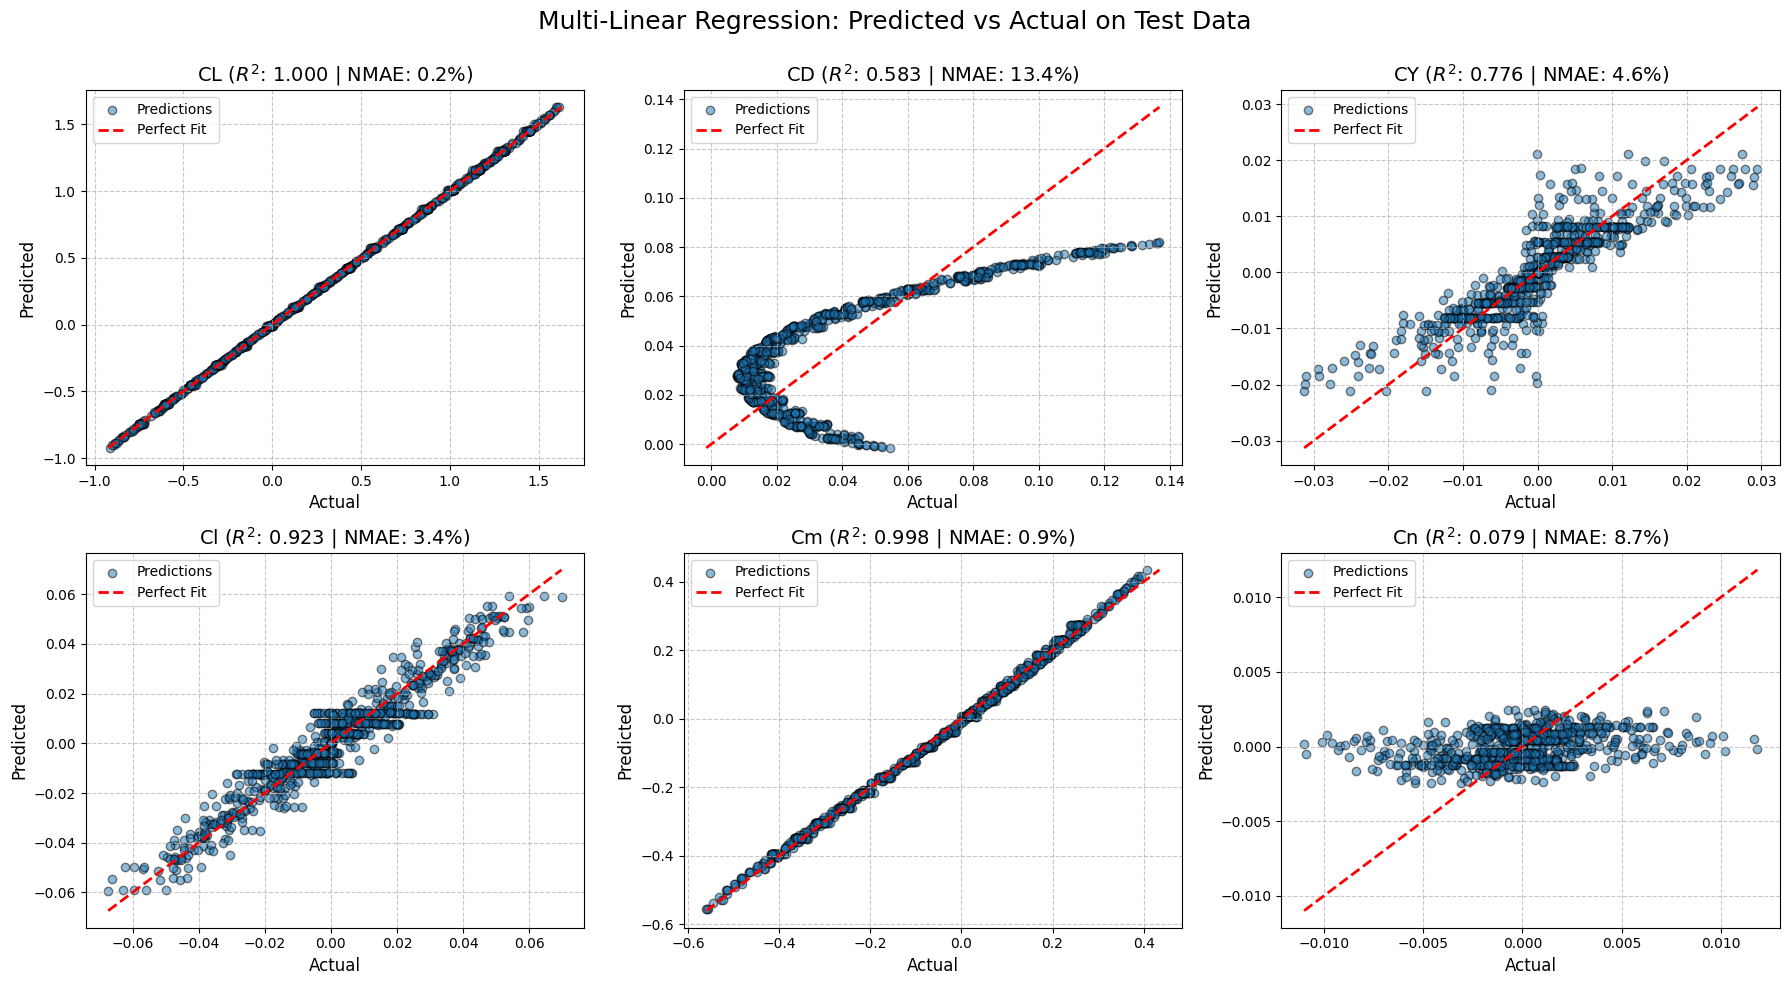

In [30]:
import matplotlib.pyplot as plt

# extracts the test features then scales adequately 
xTest = dataTest[["alpha_deg", "beta_deg", "deltaS_deg", "deltaD_deg"]]
yTest = dataTest[["CL", "CD", "CY", "Cl", "Cm", "Cn"]]

xTestScaled = xScaler.transform(xTest)

# predict using the trained model
testPred = modelLr.predict(xTestScaled)

# calculate standard MAE and R^2 for all parameters
testMaes = mean_absolute_error(yTest, testPred, multioutput='raw_values')
testR2 = r2_score(yTest, testPred, multioutput='raw_values')

parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

# plot generation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Multi-Linear Regression: Predicted vs Actual on Test Data', fontsize=18)

axes = axes.flatten()

for i, target in enumerate(parameters):
    ax = axes[i]
    actual = yTest[target].values
    predicted = testPred[:, i]
    
    # calculate NMAE (normalized by the range of actual values)
    rangeVal = actual.max() - actual.min()
    nmae = (testMaes[i] / rangeVal) * 100 if rangeVal != 0 else 0
    
    # scatter plots
    ax.scatter(actual, predicted, alpha=0.5, edgecolor='k', label='Predictions')
    
    # creates and "ideal" line
    minVal = min(actual.min(), predicted.min())
    maxVal = max(actual.max(), predicted.max())
    ax.plot([minVal, maxVal], [minVal, maxVal], 'r--', lw=2, label='Perfect Fit')
    
    # titles and stuff
    ax.set_title(f"{target} ($R^2$: {testR2[i]:.3f} | NMAE: {nmae:.1f}%)", fontsize=14)
    ax.set_xlabel('Actual', fontsize=12)
    ax.set_ylabel('Predicted', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

As the plot above shows, some of the parameters are much better suited towards linear regression than others.

+ $C_L$ & $C_m$ both exhibit a **perfectly linear** fit with very low NMAE scores, we can use this performance to gauge future model performance.
+ All of the other models however show some significant deviation from the perfect fit, in the $C_D$ plot we can see the parabolic relationship between attitude and drag (drag polar) very clearly on this graph. The other parameters have some odd relationships that do not fit to a linear regression very well.

With this in mind, we can move on to different machine learning models to better predict these non linear relationships.

## 5.2 Building gradient boosted trees 

As the previous model has shown many of these parameters are not depicted well with a linear regression. Using gradient boosted trees we can model non-linear parameters for a relativly low resource cost as is works very well with tabular data and is much simpler to run than a neural network. 

### 5.2.1 Regularization 
Because gradient boosted trees utilizes decision trees, we can't use standard ridge or lasso regularization to prevent the model from overfitting. The weights applied simply do not work with this model, however we can use `min_samples_leaf` and `max_depth` to control the fitting. 

In [ ]:
from scipy.stats import uniform, randint

# parameter directory 
paramDistributions = {
    'estimator__n_estimators': randint(100, 400), # limits number of trees 
    'estimator__learning_rate': uniform(0.01, 0.1), # throttles the changes made to subsequent trees      
    'estimator__max_depth': randint(3, 8), # limits depth of trees                
    'estimator__min_samples_leaf': randint(1, 5) # limits number of tree branches
}

### 5.2.2 Hyperparamter tuning with RandomizedSearchCV

Randomized search is generally the standard tuner for a relativley inconsequential dataset like this, while there are more advanced options randomized search offers a good balance between performance and efficiency. 

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import RandomizedSearchCV

# initilize models
baseGbr = GradientBoostingRegressor(random_state=42)
multiGbt = MultiOutputRegressor(baseGbr)


# set up RandomizedSearchCV
randomSearch = RandomizedSearchCV(
    estimator=multiGbt,
    param_distributions=paramDistributions,
    n_iter=30,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2, 
    random_state=42,
    n_jobs=1  # FIXED: Set to 1 to prevent multiprocessing kernel crashes
)

# prints each interation of hyperparameter tuning
print("Starting Hyperparameter Tuning. This may take a few minutes...")
randomSearch.fit(xTrainScaled, yTrain)

# 
print("\n--- Tuning Complete ---")

Starting Hyperparameter Tuning. This may take a few minutes...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END estimator__learning_rate=0.047454011884736254, estimator__max_depth=7, estimator__min_samples_leaf=3, estimator__n_estimators=206; total time=   2.1s
[CV] END estimator__learning_rate=0.047454011884736254, estimator__max_depth=7, estimator__min_samples_leaf=3, estimator__n_estimators=206; total time=   2.0s
[CV] END estimator__learning_rate=0.047454011884736254, estimator__max_depth=7, estimator__min_samples_leaf=3, estimator__n_estimators=206; total time=   2.0s
[CV] END estimator__learning_rate=0.047454011884736254, estimator__max_depth=7, estimator__min_samples_leaf=3, estimator__n_estimators=206; total time=   2.0s
[CV] END estimator__learning_rate=0.047454011884736254, estimator__max_depth=7, estimator__min_samples_leaf=3, estimator__n_estimators=206; total time=   1.9s
[CV] END estimator__learning_rate=0.08796910002727693, estimator__max_depth=7, e

### 5.1.3 Individual plots of gradient boosted trees

To keep things simple and relative we use the same metrics as the multi output linear regression so we can get a rough idea how the two models compare with the raw performance of each model. 


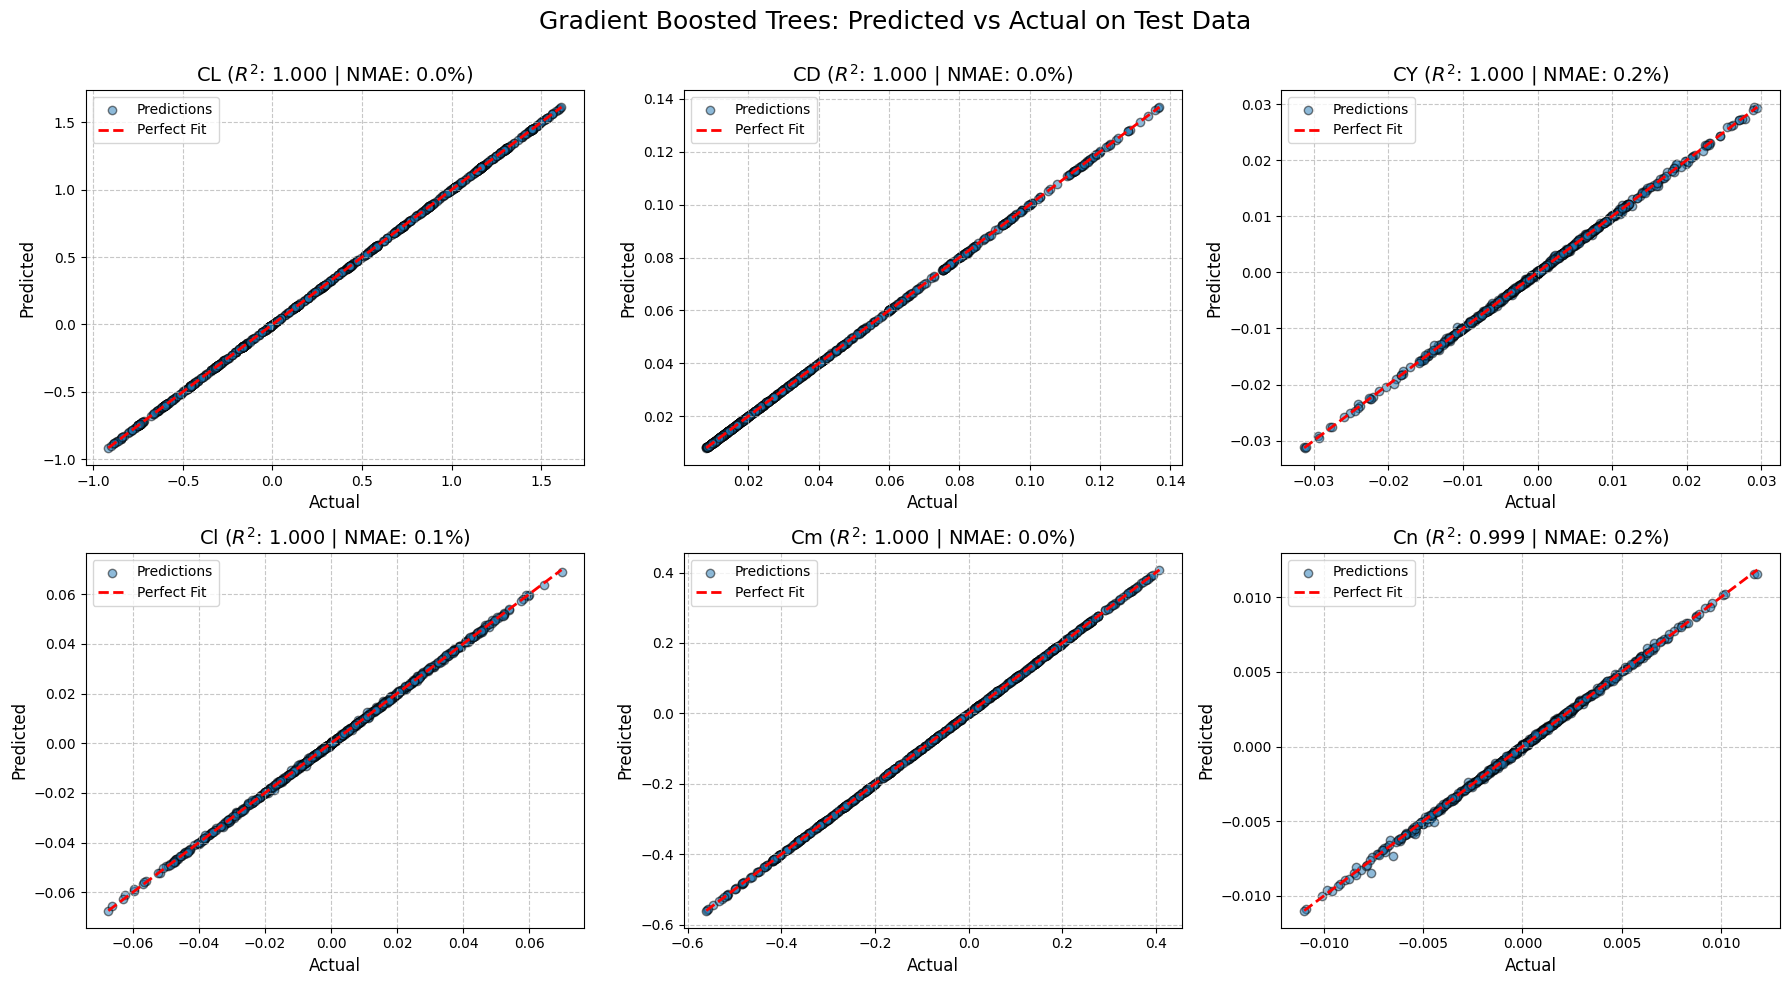

In [ ]:
import matplotlib.pyplot as plt

# extracts the test features then scales adequately 
xTest = dataTest[["alpha_deg", "beta_deg", "deltaS_deg", "deltaD_deg"]]
yTest = dataTest[["CL", "CD", "CY", "Cl", "Cm", "Cn"]]

xTestScaled = xScaler.transform(xTest)

# predict using the trained model
testPred = multiGbt.predict(xTestScaled)

# calculate standard MAE and R^2 for all parameters
testMaes = mean_absolute_error(yTest, testPred, multioutput='raw_values')
testR2 = r2_score(yTest, testPred, multioutput='raw_values')

parameters = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]

# plot generation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Gradient Boosted Trees: Predicted vs Actual on Test Data', fontsize=18)

axes = axes.flatten()

for i, target in enumerate(parameters):
    ax = axes[i]
    actual = yTest[target].values
    predicted = testPred[:, i]
    
    # calculate NMAE (normalized by the range of actual values)
    rangeVal = actual.max() - actual.min()
    nmae = (testMaes[i] / rangeVal) * 100 if rangeVal != 0 else 0
    
    # scatter plots
    ax.scatter(actual, predicted, alpha=0.5, edgecolor='k', label='Predictions')
    
    # creates and "ideal" line
    minVal = min(actual.min(), predicted.min())
    maxVal = max(actual.max(), predicted.max())
    ax.plot([minVal, maxVal], [minVal, maxVal], 'r--', lw=2, label='Perfect Fit')
    
    # titles and stuff
    ax.set_title(f"{target} ($R^2$: {testR2[i]:.3f} | NMAE: {nmae:.1f}%)", fontsize=14)
    ax.set_xlabel('Actual', fontsize=12)
    ax.set_ylabel('Predicted', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

The gradient boosted trees algorithm shows significant improvements on the linear model, particularly in the non-linear varibles mentioned earlier.

Similar to the linear model we can further improve this model by weighting performance towards more influential parameters for a controller use case. Those being:
+ $C_m$, $C_n$, $C_l$ 